In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
ruta='/content/drive/MyDrive/'
archivo='API_11_DS2_en_excel_v2_40116.xls' # Fuente: https://data.worldbank.org/topic/poverty
df=pd.read_excel(ruta+archivo,header=3)    # El encabezado está en la fila 4
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,Annualized average growth rate in per capita r...,SI.SPR.PCAP.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,"Survey mean consumption or income per capita, ...",SI.SPR.PCAP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,Annualized average growth rate in per capita r...,SI.SPR.PC40.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,"Survey mean consumption or income per capita, ...",SI.SPR.PC40,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_spr=df.groupby('Indicator Code').get_group('SI.POV.UMIC.GP')
df_spr.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
4,Aruba,ABW,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,Africa Eastern and Southern,AFE,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,Afghanistan,AFG,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Visualización de datos faltantes
## Mapa de calor

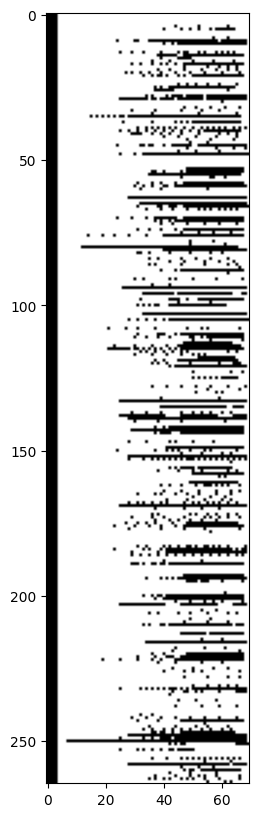

In [ ]:
df_nans=df_spr.isna()           # Evaluamos cuáles son datos nulos y cuáles ño
plt.figure(figsize=(3,10))
plt.imshow(df_nans,cmap='gray') # Mapa de calor en blanco (NaN) y negro (no nulo)

## Matriz de co-ocurrencia

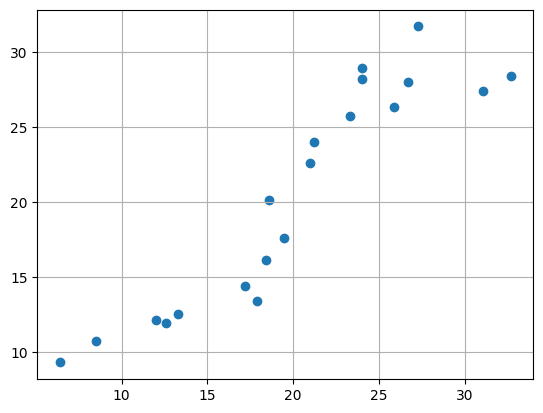

In [ ]:
# Suponemos que las variables 'Latinoamerica' (LCN) y 'Mexico' (MEX) están correlacionadas
mex=df_spr[df_spr['Country Code']=='MEX'].values[0,4:]
lcn=df_spr[df_spr['Country Code']=='LCN'].values[0,4:]
plt.scatter(mex,lcn)
plt.grid()

In [ ]:
# Cambiamos los np.NaN por 'NaN' para visualizarlos y obtenemos la matriz de co-ocurrencia
df_nans=df_spr.fillna('NaN')
pd.crosstab(df_nans[df_nans['Country Code']=='MEX'].values[0,4:],df_nans[df_nans['Country Code']=='LCN'].values[0,4:])

col_0,9.3,10.1,10.7,11.9,12.1,12.3,12.5,13.4,13.7,14.4,...,28.5,28.7,28.8,28.9,29.1,29.3,30.3,31.7,31.9,NaN
row_0,,,,,,,,,,,,,,,,,,,,,
6.4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8.5,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12.0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12.6,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13.3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17.2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
17.9,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
18.4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18.6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Tratamiento de datos faltantes
## Eliminación de datos

In [ ]:
df_spr.shape

(265, 70)

In [ ]:
# Eliminar las filas (variables) que tengan al menos un NaN
df_spr.dropna()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025


In [ ]:
# Eliminar las filas que tengan menos de 6 valores
df_spr.dropna(thresh=6)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
88,Angola,AGO,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,46.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109,Albania,ALB,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,9.6,9.3,6.6,5.0,4.9,NaN,NaN,NaN,NaN,NaN
172,United Arab Emirates,ARE,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193,Argentina,ARG,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,3.7,3.3,4.2,5.0,6.2,4.6,4.2,5.0,4.4,NaN
214,Armenia,ARM,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,15.3,15.7,16.2,17.2,16.2,16.4,17.0,16.4,12.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5464,Kosovo,XKX,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,15.3,23.4,28.1,16.5,20.7,27.2,17.0,NaN,NaN,NaN
5485,"Yemen, Rep.",YEM,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5506,South Africa,ZAF,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28.4,NaN,NaN,NaN
5527,Zambia,ZMB,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,69.6,NaN,NaN,NaN


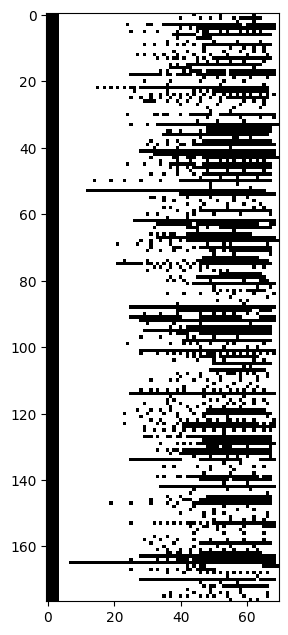

In [ ]:
df_nans=df_spr.dropna(thresh=6).isna()
plt.figure(figsize=(3,10))
plt.imshow(df_nans,cmap='gray')

In [ ]:
# Eliminar las filas que tengan solo NaNs
df_spr.dropna(how='all') # En nuestra dataset no debería tener efecto

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
4,Aruba,ABW,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,Africa Eastern and Southern,AFE,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,Afghanistan,AFG,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,Africa Western and Central,AFW,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,Angola,AGO,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,46.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5464,Kosovo,XKX,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,15.3,23.4,28.1,16.5,20.7,27.2,17.0,NaN,NaN,NaN
5485,"Yemen, Rep.",YEM,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5506,South Africa,ZAF,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28.4,NaN,NaN,NaN
5527,Zambia,ZMB,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,69.6,NaN,NaN,NaN


In [ ]:
# Aplicamos este último criterio a las columnas (observaciones)
df_spr.dropna(axis=1,how='all')

,Country Name,Country Code,Indicator Name,Indicator Code,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
4,Aruba,ABW,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,Africa Eastern and Southern,AFE,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,Afghanistan,AFG,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,Africa Western and Central,AFW,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,Angola,AGO,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,46.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5464,Kosovo,XKX,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,15.3,23.4,28.1,16.5,20.7,27.2,17.0,NaN,NaN,NaN
5485,"Yemen, Rep.",YEM,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5506,South Africa,ZAF,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28.4,NaN,NaN,NaN
5527,Zambia,ZMB,Poverty gap at $8.30 a day (2021 PPP) (%),SI.POV.UMIC.GP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,69.6,NaN,NaN,NaN


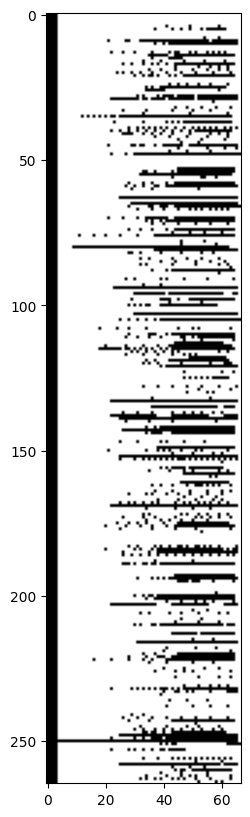

In [ ]:
df_nans=df_spr.dropna(axis=1,how='all').isna()
plt.figure(figsize=(3,10))
plt.imshow(df_nans,cmap='gray')

In [ ]:
# Eliminar las observaciones (columnas) que tengan solo NaN y las variables (filas) que tengan menos de 6 valores
df_clean=df_spr.dropna(thresh=6,axis=1).dropna(thresh=6)
df_clean.shape

(177, 50)

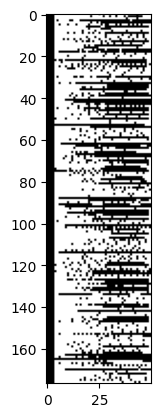

In [ ]:
plt.imshow(df_clean.isna(),cmap='gray')

## Imputación de datos

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(123)
df=pd.DataFrame(np.random.randn(100,2)+np.random.rand(2),columns=['A','B'])
df['C']=np.random.uniform(-2,3,100)
df['D']=np.round(np.random.randn(100),0)
nansA=[25,27,29,31,33]
nansB=np.random.randint(99,size=np.random.randint(20))
nansC=np.random.randint(99,size=np.random.randint(20))
nansD=np.random.randint(99,size=np.random.randint(20))
df.loc[nansA,'A']=np.nan
df.iloc[nansB,1]=np.nan
df.loc[nansC,'C']=np.nan
df.iloc[nansD,3]=np.nan
df.isna().sum()

,0
A,5
B,6
C,16
D,16


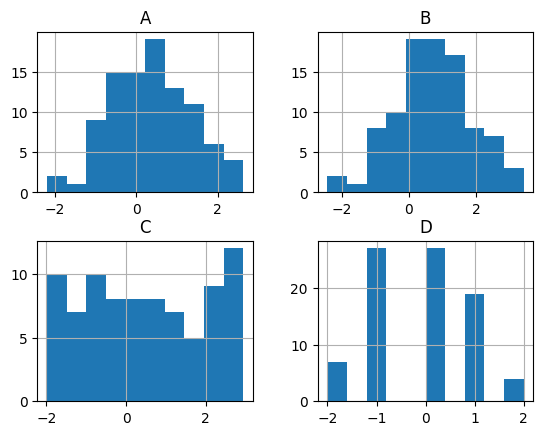

In [ ]:
H=df.hist()

<Axes: >

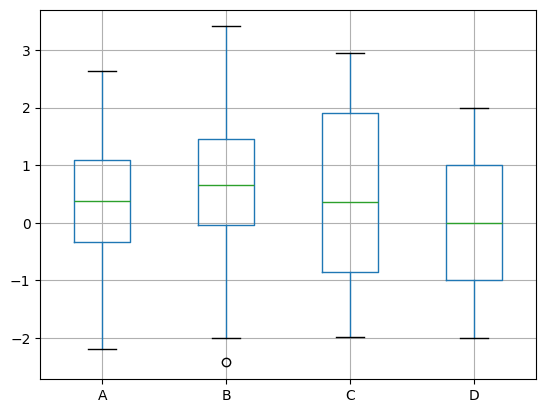

In [ ]:
df.boxplot() # Tenemos un atípico por ahí

In [ ]:
#@title Imputación usando la media aritmética y la mediana
ma=df.mean()
ma

,0
A,0.369786
B,0.683401
C,0.464562
D,-0.166667


In [ ]:
df_ma=df.fillna(ma)
# df.fillna(ma,inplace=True) Para sobreescribir la variable
df_ma.isna().sum() # Ya no tenemos ningun dato perdido

,0
A,0
B,0
C,0
D,0


In [ ]:
ma - df_ma.mean() # Conservamos la media aritmética

,0
A,0.000000e+00
B,0.000000e+00
C,0.000000e+00
D,2.775558e-17


In [ ]:
df.std() - df_ma.std() # Pero la desviación estándar disminuye

,0
A,0.025349
B,0.034935
C,0.129534
D,0.086706


array([[<Axes: title={'center': 'A'}>, <Axes: title={'center': 'B'}>],
       [<Axes: title={'center': 'C'}>, <Axes: title={'center': 'D'}>]],
      dtype=object)

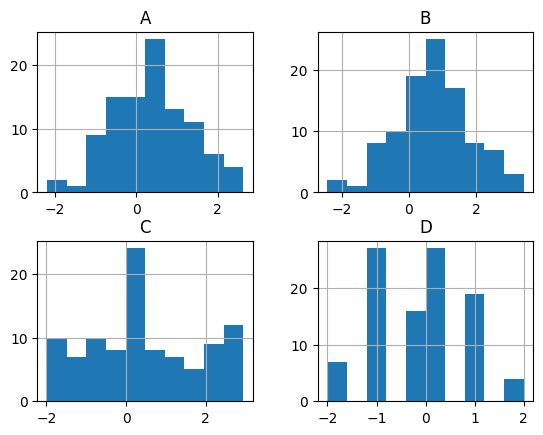

In [ ]:
df_ma.hist() # Evitamos la imputación con media o mediana en varibles con distribución Uniforme o variables discretas

In [ ]:
# Imputación con mediana
me=df.median()
df_me=df.fillna(me)
me - df_me.median()

,0
A,0.0
B,0.0
C,0.0
D,-0.0


In [ ]:
df.std() - df_me.std() # La desviación estándar disminuye

,0
A,0.025349
B,0.034918
C,0.129075
D,0.084705


In [ ]:
#@title Sustitución usando la moda
#
# Calculado desde pandas
mo=df.mode().iloc[0] # Obtenemos las datos más pequeños de los que más se repiten
mo

,0
A,-2.188429
B,-2.423264
C,-1.982339
D,-1.000000


In [ ]:
df_mo=df.fillna(df.mode().iloc[0])
df_mo.isna().sum()

,0
A,0
B,0
C,0
D,0


In [ ]:
mo-df_mo.mode().iloc[0] # La moda no cambia

,0
A,0.0
B,0.0
C,0.0
D,0.0


array([[<Axes: title={'center': 'A'}>, <Axes: title={'center': 'B'}>],
       [<Axes: title={'center': 'C'}>, <Axes: title={'center': 'D'}>]],
      dtype=object)

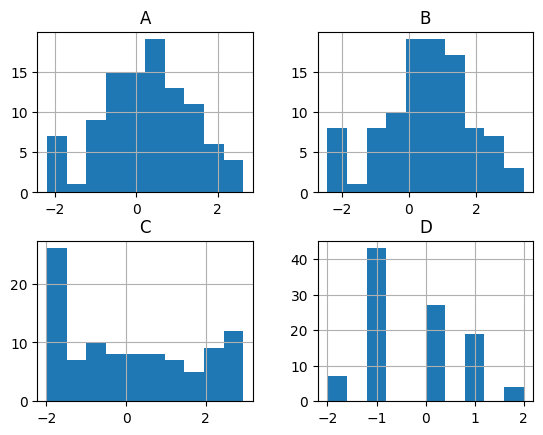

In [ ]:
df_mo.hist() # Preferimos usar la moda en variables discretas o categóricas

In [ ]:
from scipy.stats import mode

In [ ]:
# Desde stats
#
mo=mode(df,axis=0,nan_policy='omit')
mo

ModeResult(mode=array([-2.18842934, -2.42326392, -1.98233895, -1.        ]), count=array([ 1.,  1.,  1., 27.]))

In [ ]:
df_mo=df.fillna(dict(zip(df.columns,mo[0])))
df_mo.isna().sum()

,0
A,0
B,0
C,0
D,0


In [ ]:
#@title Sustitución aleatoria
df_A=df['A'].dropna()
df_A.isna().sum(),df_A.shape

(np.int64(0), (95,))

In [ ]:
df_A.iloc[np.random.randint(len(df_A)-1)]

np.float64(-0.8463180062933547)

In [ ]:
df_rand=df.copy()
for var in df:
  df_A=df[var].dropna()
  df_rand.loc[df[var].isna(),var]=df_A.iloc[np.random.randint(len(df_A)-1)] # df_rand[var].fillna(df_A.iloc[...])
df_rand.isna().sum()

,0
A,0
B,0
C,0
D,0


array([[<Axes: title={'center': 'A'}>, <Axes: title={'center': 'B'}>],
       [<Axes: title={'center': 'C'}>, <Axes: title={'center': 'D'}>]],
      dtype=object)

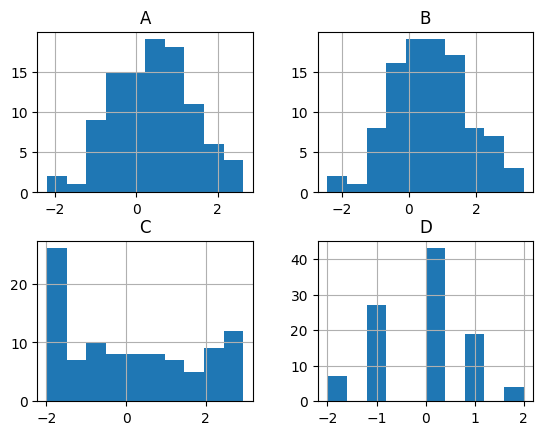

In [ ]:
df_rand.hist()

In [ ]:
df_rand=df.copy()
for var in df:
  df_A=df[var].dropna()
  for idx_null in df[var][df[var].isna()].index:
    df_rand.loc[idx_null,var]=df_A.iloc[np.random.randint(len(df_A)-1)]
df_rand.isna().sum()

,0
A,0
B,0
C,0
D,0


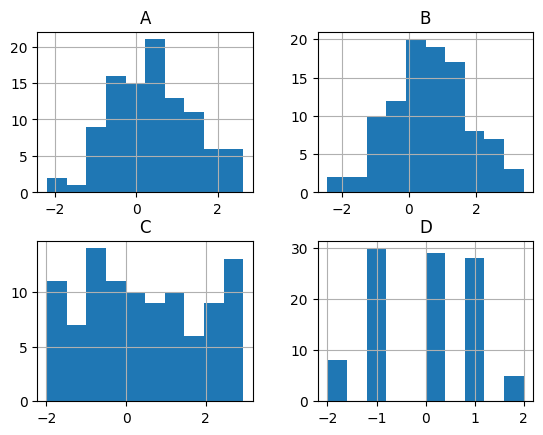

In [ ]:
H=df_rand.hist() # La imputación aleatoria la preferimos en variables con distribución Uniforme

## Usando librerías

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputador = SimpleImputer(strategy='median') # strategy='mean' (predeterminado), 'most_frequent'

In [ ]:
df_imputado=imputador.fit_transform(df)
df_imputado=pd.DataFrame(df_imputado,columns=df.columns)
df_imputado.head()

,A,B,C,D
0,-0.847381,1.805137,2.474891,-1.0
1,0.521228,-0.698504,0.367046,0.0
2,-0.340350,2.459228,-0.490266,1.0
3,-2.188429,0.378878,0.367046,-1.0
4,1.504186,-0.058949,0.697524,-1.0


In [ ]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 9.4 MB/s eta 0:00:00


In [ ]:
%%bash
pip install feature-engine

In [ ]:
from feature_engine.imputation import RandomSampleImputer

In [ ]:
otro_imputador=RandomSampleImputer()
df_imputado=otro_imputador.fit_transform(df)
df_imputado.head()

,A,B,C,D
0,-0.847381,1.805137,2.474891,-1.0
1,0.521228,-0.698504,0.309544,-1.0
2,-0.340350,2.459228,-0.490266,1.0
3,-2.188429,0.378878,0.424547,-1.0
4,1.504186,-0.058949,0.697524,-1.0


In [ ]:
# La imputación la haremos únicamente sobre la variable con distribución Uniforme
#
otro_imputador=RandomSampleImputer(variables=['C'])
df_imputado=otro_imputador.fit_transform(df)
df_imputado.isna().sum()

,0
A,5
B,6
C,0
D,16


<Axes: >

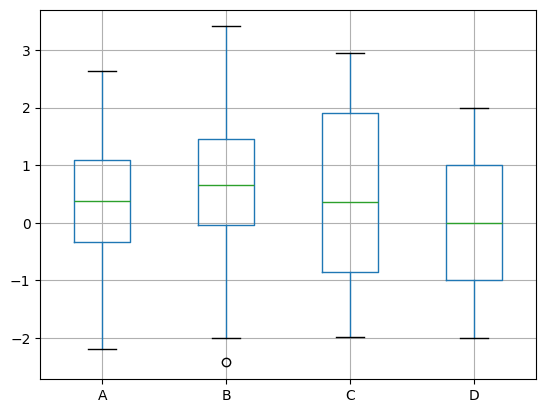

In [ ]:
df.boxplot()

### Identificación de variables para la imputación
Variable |Característica | Imputación
---|---|---
**A** | Distribución Normal | Media
**B** | Valores atípicos | Mediana
**C** | Distribución Uniforme | Aleatoria
**D** | Variable Discreta | Moda

In [50]:
df_imputado=df.copy()
df_imputado['A']=df_imputado['A'].fillna(df_imputado['A'].mean())
df_imputado['B']=df_imputado['B'].fillna(df_imputado['B'].median())
df_imputado['D']=df_imputado['D'].fillna(df_imputado['D'].mode()[0])
df_imputado.isna().sum()

,0
A,0
B,0
C,16
D,0


In [52]:
ma_A=df_imputado['A'].mean()
me_B=df_imputado['B'].median()
mo_D=df_imputado['D'].mode()[0]
data_imp={'A':ma_A,'B':me_B,'D':mo_D}
data_imp

{'A': np.float64(0.3697856520087697),
 'B': 0.6579143582795524,
 'D': np.float64(-1.0)}

In [55]:
df_imputado=df.copy()
df_imputado.fillna(data_imp,inplace=True)
df_imputado.isna().sum()

,0
A,0
B,0
C,16
D,0


In [56]:
imputador=RandomSampleImputer()
df_imputado=imputador.fit_transform(df_imputado)
df_imputado.isna().sum()

,0
A,0
B,0
C,0
D,0
